# HPO 시도 

In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler

# 경로 설정
data_dir = "/Users/taehokim/lab/BRL_AI/data"
sanitation_path = os.path.join(data_dir, 'Sanitation.xlsx')

# 소재방 불러오기
material_path = os.path.join(data_dir, 'Material.xlsx')

## 전처리 파일 (.pkl 파일불러오기)

In [2]:
import pickle
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from IPython.display import display
import os

# 전처리된 데이터 불러오기
save_dir = "/Users/taehokim/lab/BRL_AI/BRL_final/CLR_pkl" 

print("=== 전처리된 데이터 불러오기 ===")

# 1. 최종 데이터만 불러오기 (final_taxonomic_levels)
all_data_path = os.path.join(save_dir, "all_preprocessed_data.pkl")

if os.path.exists(all_data_path):
    with open(all_data_path, 'rb') as f:
        preprocessed_data = pickle.load(f)
    final_taxonomic_levels = preprocessed_data['final_taxonomic_levels']
    print(f"✅ 최종 데이터 로드 완료")
    print(f"총 taxonomy level 수: {len(final_taxonomic_levels)}")
else:
    print(f"❌ 통합 데이터 파일을 찾을 수 없습니다: {all_data_path}")

# 2. ANOVA 결과 불러오기
anova_results_path = os.path.join(save_dir, "anova_results.pkl")
if os.path.exists(anova_results_path):
    with open(anova_results_path, 'rb') as f:
        anova_results = pickle.load(f)
    print(f"✅ ANOVA 결과 로드 완료")
else:
    print(f"❌ ANOVA 결과 파일을 찾을 수 없습니다: {anova_results_path}")

# 3. 변화량 분석 결과 불러오기
change_analysis_path = os.path.join(save_dir, "change_analysis_results.pkl")
if os.path.exists(change_analysis_path):
    with open(change_analysis_path, 'rb') as f:
        change_analysis_results = pickle.load(f)
    print(f"✅ 변화량 분석 결과 로드 완료")
else:
    print(f"❌ 변화량 분석 결과 파일을 찾을 수 없습니다: {change_analysis_path}")

# 4. ANOVA 결과 검토 (상위 5개 feature만 표시)
print(f"\n=== ANOVA 결과 검토 (상위 5개 유의 Feature) ===")
for level_name in ['Phylum', 'Class', 'Order', 'Family', 'Genus']:
    if level_name in anova_results:
        anova_result_df = anova_results[level_name]['anova_result']
        significant_features = anova_results[level_name]['significant_features']
        print(f"\n[{level_name}]")
        print(f"총 유의 Feature 수: {len(significant_features)}")
        if not anova_result_df.empty:
            top_5_anova = anova_result_df.head(5)
            print(f"상위 5개 유의 Feature (p-value 기준):")
            display(top_5_anova)
        else:
            print("ANOVA 결과가 없습니다.")

# 5. 변화량 분석 결과 검토 (상위 5개만 표시)
print(f"\n=== 변화량 분석 결과 검토 (상위 5개 변화량) ===")
for level_name in ['Phylum', 'Class', 'Order', 'Family', 'Genus']:
    if level_name in change_analysis_results:
        top_features = change_analysis_results[level_name]['top_10_features'][:5]
        summary_stats = change_analysis_results[level_name]['summary_stats']
        print(f"\n[{level_name}]")
        print(f"증가 패턴: {summary_stats['increase_count']}개, 감소 패턴: {summary_stats['decrease_count']}개")
        if top_features:
            change_df = pd.DataFrame([
                {
                    'Feature': feat['feature'],
                    'Change_Amount': feat['change_amount'],
                    'Abs_Change': feat['abs_change'],
                    'Trend': feat['trend'],
                    'Min_Day': feat['min_day'],
                    'Max_Day': feat['max_day']
                }
                for feat in top_features
            ])
            print(f"상위 5개 변화량 Feature:")
            display(change_df)
        else:
            print("변화량 분석 결과가 없습니다.")

# 6. 데이터 구조 간단 확인
print(f"\n=== 데이터 구조 요약 ===")
for level_name, merged_df in final_taxonomic_levels:
    feature_cols = [col for col in merged_df.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS']]
    significant_features = anova_results[level_name]['significant_features']
    print(f"[{level_name}] 샘플: {len(merged_df)}, 전체 Feature: {len(feature_cols)}, ANOVA 유의: {len(significant_features)}")

# 7. 특정 레벨 선택 함수 (HPO에서 사용할 수 있도록)
def get_level_data(level_name):
    """특정 taxonomy level의 데이터를 반환하는 함수"""
    for name, data in final_taxonomic_levels:
        if name.lower() == level_name.lower():
            feature_cols = [col for col in data.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS']]
            return {
                'data': data,
                'features': data[feature_cols],
                'feature_names': feature_cols,
                'tpc': data['TPC (log CFU/g)'],
                'tbars': data['TBARS'],
                'description': data['Description'],
                'significant_features': anova_results[name]['significant_features'],
                'anova_results': anova_results[name],
                'change_analysis': change_analysis_results[name]
            }
    return None

print(f"\n=== 데이터 로딩 완료 ===")
print("이제 하이퍼파라미터 최적화를 진행할 수 있습니다.")

# 8. 사용 예시
print(f"\n=== 사용 예시 ===")
print("# 특정 레벨 데이터 가져오기:")
print("genus_data = get_level_data('genus')")
print("X = genus_data['features']  # Feature 데이터")
print("y_tpc = genus_data['tpc']   # TPC 타겟")
print("y_tbars = genus_data['tbars']  # TBARS 타겟")
print("significant_features = genus_data['significant_features']  # ANOVA 유의 Feature")
print("top_change_features = genus_data['change_analysis']['top_10_features']  # 변화량 상위 Feature")

=== 전처리된 데이터 불러오기 ===
✅ 최종 데이터 로드 완료
총 taxonomy level 수: 5
✅ ANOVA 결과 로드 완료
✅ 변화량 분석 결과 로드 완료

=== ANOVA 결과 검토 (상위 5개 유의 Feature) ===

[Phylum]
총 유의 Feature 수: 12
상위 5개 유의 Feature (p-value 기준):


,feature,f_statistic,p_value,fdr
6,p__Deinococcota,34.734869,4.434908e-37,5.321890e-36
2,p__Bacteroidota,32.394400,4.045796e-35,2.427478e-34
4,p__Proteobacteria,14.010545,6.247631e-17,2.499053e-16
3,p__Chloroflexi,10.326593,1.505222e-12,4.515667e-12
11,p__Acidobacteriota,10.256684,1.834053e-12,4.401728e-12



[Class]
총 유의 Feature 수: 13
상위 5개 유의 Feature (p-value 기준):


,feature,f_statistic,p_value,fdr
5,c__Alphaproteobacteria,39.072509,1.516817e-40,1.971863e-39
6,c__Deinococci,35.573071,9.135277e-38,5.937930e-37
2,c__Bacteroidia,35.004501,2.662388e-37,1.153701e-36
4,c__Gammaproteobacteria,17.011379,2.684438e-20,8.724422e-20
10,c__Negativicutes,12.885207,1.273132e-15,3.310143e-15



[Order]
총 유의 Feature 수: 48
상위 5개 유의 Feature (p-value 기준):


...


[Family]
증가 패턴: 85개, 감소 패턴: 0개
상위 5개 변화량 Feature:


,Feature,Change_Amount,Abs_Change,Trend,Min_Day,Max_Day
0,f__Chitinibacteraceae,14.204433,14.204433,증가,3,18
1,f__Bacillaceae,13.781898,13.781898,감소 후 증가,18,3
2,f__Xanthomonadaceae,13.613548,13.613548,감소 후 증가,18,3
3,f__Vagococcaceae,13.444156,13.444156,증가,5,18
4,f__Carnobacteriaceae,13.438775,13.438775,증가,0,18



[Genus]
증가 패턴: 133개, 감소 패턴: 0개
상위 5개 변화량 Feature:


,Feature,Change_Amount,Abs_Change,Trend,Min_Day,Max_Day
0,g__Macrococcus,14.233680,14.233680,감소 후 증가,18,3
1,g__Iodobacter,14.092941,14.092941,증가,3,18
2,g__Bacillus,14.003815,14.003815,감소 후 증가,18,3
3,g__Xanthomonas,13.752768,13.752768,감소 후 증가,18,3
4,g__Streptococcus,13.549499,13.549499,감소 후 증가,18,3



=== 데이터 구조 요약 ===
[Phylum] 샘플: 270, 전체 Feature: 12, ANOVA 유의: 12
[Class] 샘플: 270, 전체 Feature: 13, ANOVA 유의: 13
[Order] 샘플: 270, 전체 Feature: 48, ANOVA 유의: 48
[Family] 샘플: 270, 전체 Feature: 85, ANOVA 유의: 85
[Genus] 샘플: 270, 전체 Feature: 133, ANOVA 유의: 133

=== 데이터 로딩 완료 ===
이제 하이퍼파라미터 최적화를 진행할 수 있습니다.

=== 사용 예시 ===
# 특정 레벨 데이터 가져오기:
genus_data = get_level_data('genus')
X = genus_data['features']  # Feature 데이터
y_tpc = genus_data['tpc']   # TPC 타겟
y_tbars = genus_data['tbars']  # TBARS 타겟
significant_features = genus_data['significant_features']  # ANOVA 유의 Feature
top_change_features = genus_data['change_analysis']['top_10_features']  # 변화량 상위 Feature


In [3]:
# 각 taxonomy level별 상세 feature 정보 확인
print("=== Taxonomy Level별 Feature 상세 정보 ===")

feature_summary = []

for level_name, merged_df in final_taxonomic_levels:
    feature_cols = [col for col in merged_df.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS']]
    significant_features = anova_results[level_name]['significant_features']
    
    # 각 레벨별 정보 수집
    level_info = {
        'Level': level_name,
        'Total_Features': len(feature_cols),
        'ANOVA_Significant': len(significant_features),
        'Sample_Count': len(merged_df),
        'Significant_Ratio': f"{len(significant_features)/len(feature_cols)*100:.1f}%" if feature_cols else "0%"
    }
    feature_summary.append(level_info)
    
    print(f"\n[{level_name}]")
    print(f"  전체 Feature 수: {len(feature_cols)}")
    print(f"  ANOVA 유의 Feature 수: {len(significant_features)}")
    print(f"  유의 Feature 비율: {len(significant_features)/len(feature_cols)*100:.1f}%")
    print(f"  총 샘플 수: {len(merged_df)}")
    
    # Feature 이름 예시 (처음 5개)
    print(f"  Feature 예시 (처음 5개): {feature_cols[:5]}")
    
    # ANOVA 유의 Feature 예시 (처음 5개)
    if significant_features:
        print(f"  유의 Feature 예시 (처음 5개): {significant_features[:5]}")
    else:
        print(f"  유의한 Feature 없음")
    
    # Feature 명명 규칙 확인 (prefix 확인)
    if feature_cols:
        prefixes = set([col.split('__')[0] + '__' for col in feature_cols if '__' in col])
        print(f"  Feature prefix: {list(prefixes)}")

# Summary Table 생성
summary_df = pd.DataFrame(feature_summary)
print(f"\n=== Feature 수 요약 테이블 ===")
print(summary_df.to_string(index=False))

# 시각적 요약
print(f"\n=== 레벨별 Feature 수 비교 ===")
for info in feature_summary:
    level = info['Level']
    total = info['Total_Features']
    significant = info['ANOVA_Significant']
    bar_length = 50
    
    # 막대그래프 스타일로 표시
    total_bar = '█' * min(int(total/10), bar_length)
    sig_bar = '▓' * min(int(significant/10), bar_length)
    
    print(f"{level:8} │ 전체: {total:4d} {total_bar}")
    print(f"         │ 유의: {significant:4d} {sig_bar}")
    print(f"         │ 비율: {info['Significant_Ratio']:>6}")
    print("─" * 60)

# 전체 통계
total_all_features = sum([info['Total_Features'] for info in feature_summary])
total_significant_features = sum([info['ANOVA_Significant'] for info in feature_summary])

print(f"\n=== 전체 통계 ===")
print(f"모든 레벨 전체 Feature 합계: {total_all_features}")
print(f"모든 레벨 유의 Feature 합계: {total_significant_features}")
print(f"전체 유의 Feature 비율: {total_significant_features/total_all_features*100:.1f}%")

# 레벨별 Feature 밀도 (Feature 수 / 샘플 수)
print(f"\n=== Feature 밀도 (Feature 수 / 샘플 수) ===")
for info in feature_summary:
    density = info['Total_Features'] / info['Sample_Count']
    sig_density = info['ANOVA_Significant'] / info['Sample_Count']
    print(f"{info['Level']:8} │ 전체: {density:.2f} │ 유의: {sig_density:.2f}")

=== Taxonomy Level별 Feature 상세 정보 ===

[Phylum]
  전체 Feature 수: 12
  ANOVA 유의 Feature 수: 12
  유의 Feature 비율: 100.0%
  총 샘플 수: 270
  Feature 예시 (처음 5개): ['p__Firmicutes', 'p__Actinobacteriota', 'p__Bacteroidota', 'p__Chloroflexi', 'p__Proteobacteria']
  유의 Feature 예시 (처음 5개): ['p__Deinococcota', 'p__Bacteroidota', 'p__Proteobacteria', 'p__Chloroflexi', 'p__Acidobacteriota']
  Feature prefix: ['p__']

[Class]
  전체 Feature 수: 13
  ANOVA 유의 Feature 수: 13
  유의 Feature 비율: 100.0%
  총 샘플 수: 270
  Feature 예시 (처음 5개): ['c__Bacilli', 'c__Actinobacteria', 'c__Bacteroidia', 'c__Chloroflexia', 'c__Gammaproteobacteria']
  유의 Feature 예시 (처음 5개): ['c__Alphaproteobacteria', 'c__Deinococci', 'c__Bacteroidia', 'c__Gammaproteobacteria', 'c__Negativicutes']
  Feature prefix: ['c__']

[Order]
  전체 Feature 수: 48
  ANOVA 유의 Feature 수: 48
  유의 Feature 비율: 100.0%
  총 샘플 수: 270
  Feature 예시 (처음 5개): ['o__Lactobacillales', 'o__Corynebacteriales', 'o__Flavobacteriales', 'o__Pseudomonadales', 'o__Bacilli(c)']
  유의 

## 1. HPO 분석 전 dataset 구분

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("=== HPO 분석을 위한 데이터셋 구분 ===")

# 각 taxonomy level별로 TPC와 TBARS 데이터셋을 별도로 생성
tpc_datasets = {}
tbars_datasets = {}

for level_name, merged_df in final_taxonomic_levels:
    # Feature 컬럼들 (Description, TPC, TBARS 제외)
    feature_cols = [col for col in merged_df.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS']]
    
    # 1. TPC 데이터셋 생성 (Features + TPC)
    tpc_df = merged_df[['Description'] + feature_cols + ['TPC (log CFU/g)']].copy()
    tpc_datasets[level_name] = {
        'data': tpc_df,
        'features': tpc_df[feature_cols],
        'target': tpc_df['TPC (log CFU/g)'],
        'feature_names': feature_cols,
        'target_name': 'TPC (log CFU/g)',
        'description': tpc_df['Description'],
        'significant_features': anova_results[level_name]['significant_features']
    }
    
    # 2. TBARS 데이터셋 생성 (Features + TBARS)
    tbars_df = merged_df[['Description'] + feature_cols + ['TBARS']].copy()
    tbars_datasets[level_name] = {
        'data': tbars_df,
        'features': tbars_df[feature_cols],
        'target': tbars_df['TBARS'],
        'feature_names': feature_cols,
        'target_name': 'TBARS',
        'description': tbars_df['Description'],
        'significant_features': anova_results[level_name]['significant_features']
    }
    
    print(f"\n[{level_name}]")
    print(f"  Feature 수: {len(feature_cols)}")
    print(f"  샘플 수: {len(merged_df)}")
    print(f"  TPC 범위: {tpc_df['TPC (log CFU/g)'].min():.2f} ~ {tpc_df['TPC (log CFU/g)'].max():.2f}")
    print(f"  TBARS 범위: {tbars_df['TBARS'].min():.2f} ~ {tbars_df['TBARS'].max():.2f}")
    print(f"  ANOVA 유의 Feature 수: {len(anova_results[level_name]['significant_features'])}")

# 데이터셋 접근 함수들
def get_tpc_dataset(level_name):
    """특정 taxonomy level의 TPC 데이터셋을 반환"""
    if level_name in tpc_datasets:
        return tpc_datasets[level_name]
    else:
        print(f"Level '{level_name}' not found. Available levels: {list(tpc_datasets.keys())}")
        return None

def get_tbars_dataset(level_name):
    """특정 taxonomy level의 TBARS 데이터셋을 반환"""
    if level_name in tbars_datasets:
        return tbars_datasets[level_name]
    else:
        print(f"Level '{level_name}' not found. Available levels: {list(tbars_datasets.keys())}")
        return None

def get_dataset_summary():
    """전체 데이터셋 요약 정보 출력"""
    print("\n=== 데이터셋 요약 ===")
    print(f"{'Level':<10} {'Samples':<8} {'Features':<10} {'ANOVA Sig':<12} {'TPC Range':<15} {'TBARS Range':<15}")
    print("-" * 80)
    
    for level_name in tpc_datasets.keys():
        tpc_data = tpc_datasets[level_name]
        tbars_data = tbars_datasets[level_name]
        
        sample_count = len(tpc_data['data'])
        feature_count = len(tpc_data['feature_names'])
        sig_count = len(tpc_data['significant_features'])
        
        tpc_min, tpc_max = tpc_data['target'].min(), tpc_data['target'].max()
        tbars_min, tbars_max = tbars_data['target'].min(), tbars_data['target'].max()
        
        print(f"{level_name:<10} {sample_count:<8} {feature_count:<10} {sig_count:<12} "
              f"{tpc_min:.1f}-{tpc_max:.1f}{'':>6} {tbars_min:.1f}-{tbars_max:.1f}")

# 요약 정보 출력
get_dataset_summary()


=== HPO 분석을 위한 데이터셋 구분 ===

[Phylum]
  Feature 수: 12
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 12

[Class]
  Feature 수: 13
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 13



[Order]
  Feature 수: 48
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 48

[Family]
  Feature 수: 85
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 85

[Genus]
  Feature 수: 133
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 133

=== 데이터셋 요약 ===
Level      Samples  Features   ANOVA Sig    TPC Range       TBARS Range    
--------------------------------------------------------------------------------
Phylum     270      12         12           2.1-8.6       0.1-0.6
Class      270      13         13           2.1-8.6       0.1-0.6
Order      270      48         48           2.1-8.6       0.1-0.6
Family     270      85         85           2.1-8.6       0.1-0.6
Genus      270      133        133          2.1-8.6       0.1-0.6


In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("=== HPO 분석을 위한 데이터셋 구분 ===")

# 각 taxonomy level별로 TPC와 TBARS 데이터셋을 별도로 생성 (Description 제거)
tpc_datasets = {}
tbars_datasets = {}

for level_name, merged_df in final_taxonomic_levels:
    # Feature 컬럼들 (Description, TPC, TBARS 제외)
    feature_cols = [col for col in merged_df.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS']]
    
    # 1. TPC 데이터셋 생성 (Features + TPC, Description 제거)
    tpc_df = merged_df[feature_cols + ['TPC (log CFU/g)']].copy()
    # TPC를 첫 번째 열로 이동
    tpc_df = tpc_df[['TPC (log CFU/g)'] + feature_cols]
    
    tpc_datasets[level_name] = {
        'data': tpc_df,
        'features': tpc_df[feature_cols],
        'target': tpc_df['TPC (log CFU/g)'],
        'feature_names': feature_cols,
        'target_name': 'TPC (log CFU/g)',
        'significant_features': anova_results[level_name]['significant_features']
    }
    
    # 2. TBARS 데이터셋 생성 (Features + TBARS, Description 제거)
    tbars_df = merged_df[feature_cols + ['TBARS']].copy()
    # TBARS를 첫 번째 열로 이동
    tbars_df = tbars_df[['TBARS'] + feature_cols]
    
    tbars_datasets[level_name] = {
        'data': tbars_df,
        'features': tbars_df[feature_cols],
        'target': tbars_df['TBARS'],
        'feature_names': feature_cols,
        'target_name': 'TBARS',
        'significant_features': anova_results[level_name]['significant_features']
    }
    
    print(f"\n[{level_name}]")
    print(f"  Feature 수: {len(feature_cols)}")
    print(f"  샘플 수: {len(merged_df)}")
    print(f"  TPC 범위: {tpc_df['TPC (log CFU/g)'].min():.2f} ~ {tpc_df['TPC (log CFU/g)'].max():.2f}")
    print(f"  TBARS 범위: {tbars_df['TBARS'].min():.2f} ~ {tbars_df['TBARS'].max():.2f}")
    print(f"  ANOVA 유의 Feature 수: {len(anova_results[level_name]['significant_features'])}")

# 데이터셋 접근 함수들
def get_tpc_dataset(level_name):
    """특정 taxonomy level의 TPC 데이터셋을 반환"""
    if level_name in tpc_datasets:
        return tpc_datasets[level_name]
    else:
        print(f"Level '{level_name}' not found. Available levels: {list(tpc_datasets.keys())}")
        return None

def get_tbars_dataset(level_name):
    """특정 taxonomy level의 TBARS 데이터셋을 반환"""
    if level_name in tbars_datasets:
        return tbars_datasets[level_name]
    else:
        print(f"Level '{level_name}' not found. Available levels: {list(tbars_datasets.keys())}")
        return None

def get_dataset_summary():
    """전체 데이터셋 요약 정보 출력"""
    print("\n=== 데이터셋 요약 ===")
    print(f"{'Level':<10} {'Samples':<8} {'Features':<10} {'ANOVA Sig':<12} {'TPC Range':<15} {'TBARS Range':<15}")
    print("-" * 80)
    
    for level_name in tpc_datasets.keys():
        tpc_data = tpc_datasets[level_name]
        tbars_data = tbars_datasets[level_name]
        
        sample_count = len(tpc_data['data'])
        feature_count = len(tpc_data['feature_names'])
        sig_count = len(tpc_data['significant_features'])
        
        tpc_min, tpc_max = tpc_data['target'].min(), tpc_data['target'].max()
        tbars_min, tbars_max = tbars_data['target'].min(), tbars_data['target'].max()
        
        print(f"{level_name:<10} {sample_count:<8} {feature_count:<10} {sig_count:<12} "
              f"{tpc_min:.1f}-{tpc_max:.1f}{'':>6} {tbars_min:.1f}-{tbars_max:.1f}")

# 요약 정보 출력
get_dataset_summary()

# 검토를 위해 데이터셋 구조 확인
print("\n=== TPC 및 TBARS 데이터셋 구조 검토 ===")

# TPC 데이터셋 확인
print("\n=== TPC 데이터셋 검토 ===")
for level_name in tpc_datasets.keys():
    tpc_data = tpc_datasets[level_name]
    print(f"\n[{level_name} - TPC 데이터셋]")
    display(tpc_data['data'].head(5))

print("\n" + "="*80)

# TBARS 데이터셋 확인
print("\n=== TBARS 데이터셋 검토 ===")
for level_name in tbars_datasets.keys():
    tbars_data = tbars_datasets[level_name]
    print(f"\n[{level_name} - TBARS 데이터셋]")
    display(tbars_data['data'].head(5))

print("\n=== 데이터셋 준비 완료 ===")
print("Description 컬럼이 제거되고 타겟 변수가 첫 번째 열로 배치된 최종 데이터셋")

=== HPO 분석을 위한 데이터셋 구분 ===

[Phylum]
  Feature 수: 12
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 12

[Class]
  Feature 수: 13
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 13

[Order]
  Feature 수: 48
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 48

[Family]
  Feature 수: 85
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 85

[Genus]
  Feature 수: 133
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 133

=== 데이터셋 요약 ===
Level      Samples  Features   ANOVA Sig    TPC Range       TBARS Range    
--------------------------------------------------------------------------------
Phylum     270      12         12           2.1-8.6       0.1-0.6
Class      270      13         13           2.1-8.6       0.1-0.6
Order      270      48         48           2.1-8.6       0.1-0.6
Family     270      85         85           2.1-8.6      

,TPC (log CFU/g),p__Firmicutes,p__Actinobacteriota,p__Bacteroidota,p__Chloroflexi,p__Proteobacteria,p__Cyanobacteria,p__Deinococcota,p__Bacteria(d),p__Bdellovibrionota,p__Campilobacterota,p__Planctomycetota,p__Acidobacteriota
0,3.681241,15.196176,12.845909,12.220203,-1.943324,16.094118,-1.943324,-1.943324,-1.943324,-1.943324,-1.943324,-1.943324,-1.943324
1,3.922395,15.702072,11.650287,11.198302,-2.292540,15.001785,-2.292540,10.638686,-2.292540,-2.292540,-2.292540,-2.292540,-2.292540
2,4.137584,15.706135,10.688193,10.331518,-2.196729,15.298351,-2.196729,9.484220,-2.196729,-2.196729,-2.196729,-2.196729,-2.196729
3,3.792392,15.616642,11.564443,12.471164,-1.916638,15.930267,-1.916638,-1.916638,-1.916638,-1.916638,-1.916638,-1.916638,-1.916638
4,3.462398,16.526635,13.301115,10.299594,-1.516184,15.657767,-1.516184,-1.516184,-1.516184,-1.516184,-1.516184,-1.516184,-1.516184



[Class - TPC 데이터셋]


,TPC (log CFU/g),c__Bacilli,c__Actinobacteria,c__Bacteroidia,c__Chloroflexia,c__Gammaproteobacteria,c__Alphaproteobacteria,c__Deinococci,c__Bacteria(d),c__Bdellovibrionia,c__Clostridia,c__Negativicutes,c__Campylobacteria,c__Planctomycetes
0,3.681241,15.703688,13.360095,12.734389,-1.429139,16.593745,12.371483,-1.429139,-1.429139,-1.429139,10.697507,-1.429139,-1.429139,-1.429139
1,3.922395,16.377865,12.328454,11.876469,-1.614374,15.636006,12.533248,11.316853,-1.614374,-1.614374,10.336024,-1.614374,-1.614374,-1.614374
2,4.137584,16.538631,11.520689,11.164014,-1.364233,16.112774,12.108476,10.316716,-1.364233,-1.364233,-1.364233,-1.364233,-1.364233,-1.364233
3,3.792392,15.864001,11.837800,12.744521,-1.643282,16.176024,12.599940,-1.643282,-1.643282,-1.643282,11.928771,10.872719,-1.643282,-1.643282
4,3.462398,17.034188,13.808667,11.263140,-1.008631,16.138652,12.527734,-1.008631,-1.008631,-1.008631,-1.008631,-1.008631,-1.008631,-1.008631



[Order - TPC 데이터셋]


...


[Family - TBARS 데이터셋]


,TBARS,f__Leuconostocaceae,f__Corynebacteriaceae,f__Streptococcaceae,f__Weeksellaceae,f__Moraxellaceae,f__Lactobacillaceae,f__Bacilli(c),f__Pseudomonadaceae,f__Beijerinckiaceae,...,f__Selenomonadaceae,f__Aerococcaceae,f__Cellulomonadaceae,f__Sphingobacteriales_env.OPS_17,f__Crocinitomicaceae,f__Gammaproteobacteria_Incertae_Sedis_Unknown_Family,f__Reyranellaceae,f__Xanthobacteraceae,f__Hafniaceae,f__Caedibacteraceae
0,0.290,13.686602,-1.233251,15.347742,12.097367,14.623096,11.586542,-1.233251,15.443756,-1.233251,...,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251
1,0.190,14.480066,11.001907,16.188175,10.491082,13.835120,11.471911,-1.459316,14.885531,11.001907,...,-1.459316,-1.459316,-1.459316,-1.459316,-1.234129,-0.497137,-1.459316,12.165058,-1.459316,-1.459316
2,0.170,14.213649,-1.273963,16.361960,10.546857,14.271219,10.930723,-1.273963,15.012157,11.387816,...,-1.273963,-0.819699,-1.273963,-1.273963,-1.273963,-1.273963,-1.273963,-1.273963,-1.273963,-1.273963
3,0.155,13.966111,11.294618,15.308920,10.521428,13.829535,11.502257,-1.706890,15.109791,11.620041,...,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890
4,0.200,14.185991,-0.794564,15.551203,10.546857,14.223405,10.930723,-0.794564,15.436428,-0.794564,...,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564



[Genus - TBARS 데이터셋]


,TBARS,g__Leuconostoc,g__Corynebacterium,g__Lactococcus,g__Chryseobacterium,g__Acinetobacter,g__Lactobacillus,g__Bacilli(c),g__Pseudomonas,g__Methylobacterium-Methylorubrum,...,g__Hafnia-Obesumbacterium,g__Dermacoccus,g__Caulobacter,g__Polaromonas,g__Curtobacterium,g__Caulobacteraceae(f).1,g__Selenomonas,g__Lawsonella,g__Bradyrhizobium,g__Candidatus_Nucleicultrix
0,0.290,14.240704,-0.679150,15.901843,12.651469,15.031015,12.140643,-0.679150,15.997858,-0.679150,...,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150
1,0.190,15.016541,11.677219,16.801183,11.166393,14.486621,12.147222,-0.784004,15.560842,11.677219,...,-0.784004,-0.784004,-0.784004,-0.784004,-0.784004,-0.784004,-0.784004,-0.784004,12.840369,-0.784004
2,0.170,14.665917,-0.760607,16.777323,10.286211,14.178439,11.347737,-0.760607,15.525513,10.920342,...,-0.760607,-0.760607,-0.760607,-0.469307,-0.760607,-0.760607,-0.760607,-0.760607,-0.760607,-0.760607
3,0.155,14.573999,11.962799,15.908108,11.189609,14.226163,12.170438,-1.038709,15.777972,12.288221,...,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709
4,0.200,14.793426,-0.453414,15.892353,10.286211,14.306726,11.347737,-0.453414,15.777578,-0.453414,...,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414



=== 데이터셋 준비 완료 ===
Description 컬럼이 제거되고 타겟 변수가 첫 번째 열로 배치된 최종 데이터셋


# 데이터셋 변수 

## 📊 HPO용 데이터셋 딕셔너리

### TPC 예측용 데이터셋
- **`tpc_datasets`**: 모든 taxonomy level의 TPC 데이터셋이 포함된 딕셔너리
  - `tpc_datasets['Phylum']`: Phylum level + TPC
  - `tpc_datasets['Class']`: Class level + TPC
  - `tpc_datasets['Order']`: Order level + TPC
  - `tpc_datasets['Family']`: Family level + TPC
  - `tpc_datasets['Genus']`: Genus level + TPC

### TBARS 예측용 데이터셋
- **`tbars_datasets`**: 모든 taxonomy level의 TBARS 데이터셋이 포함된 딕셔너리
  - `tbars_datasets['Phylum']`: Phylum level + TBARS
  - `tbars_datasets['Class']`: Class level + TBARS
  - `tbars_datasets['Order']`: Order level + TBARS
  - `tbars_datasets['Family']`: Family level + TBARS
  - `tbars_datasets['Genus']`: Genus level + TBARS

## ========================================================================

## 1. TPC Label Hyper parameter Optimizing 

### 1-1. Optuna TPE Samnpler 

In [6]:
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=== TPC Label HPO 시작 (TPE 최적화) ===")

# TPC 데이터셋에서 Genus level 사용 - Description 포함된 원본 데이터 사용
for level_name, merged_df in final_taxonomic_levels:
    if level_name == 'Genus':
        # Description 포함하여 전체 데이터 복사
        df_tpc = merged_df[['Description', 'TPC (log CFU/g)', 'TBARS']].copy()
        break

# Day 컬럼 추가 (Description에서 추출)
if 'Day' not in df_tpc.columns:
    df_tpc['Day'] = df_tpc['Description'].str.extract(r'A(\d+)', expand=False).astype(int)

print(f"데이터 형태: {df_tpc.shape}")
print(f"Day 분포: {df_tpc['Day'].value_counts().sort_index()}")

# 라벨링 함수: TPC 기준만 사용
def label_by_tpc(df, tpc_thr_low, tpc_thr_high):
    # 신선(0): TPC < tpc_thr_low
    # 중간부패(2): tpc_thr_low ≤ TPC < tpc_thr_high
    # 부패(1): TPC ≥ tpc_thr_high
    cond_fresh = df['TPC (log CFU/g)'] < tpc_thr_low
    cond_decay = df['TPC (log CFU/g)'] >= tpc_thr_high
    label = np.where(cond_fresh, 0, np.where(cond_decay, 1, 2))
    return label

# 개선된 평가 함수 (1/3 비율 패널티 제거, 각 라벨이 3일 미만 등장하면 패널티 추가)
def evaluate_labeling(df, label_col='Label'):
    df = df.copy()
    df['Day'] = df['Day'].astype(int)
    day_list = sorted(df['Day'].unique())
    day_stats = df.groupby('Day')[label_col].value_counts().unstack(fill_value=0)
    penalty = 0

    # 전체 및 라벨별 샘플 수 계산 (먼저 계산)
    total = len(df)
    n_fresh = (df[label_col] == 0).sum()
    n_decay = (df[label_col] == 1).sum()
    n_middle = (df[label_col] == 2).sum()

    # 1. ✅ 생물학적 흐름 조건
    n_fresh_0 = day_stats.loc[0, 0] if 0 in day_stats.columns and 0 in day_stats.index else 0
    if n_fresh_0 < 15:
        penalty += (15 - n_fresh_0) * 2

    n_fresh_9 = day_stats.loc[9, 0] if 0 in day_stats.columns and 9 in day_stats.index else 0
    if n_fresh_9 < 5:
        penalty += (5 - n_fresh_9) * 2

    n_decay_18 = day_stats.loc[18, 1] if 1 in day_stats.columns and 18 in day_stats.index else 0
    if n_decay_18 < 15:
        penalty += (15 - n_decay_18) * 2

    # 2. ✅ 중간 클래스 확보 조건
    if n_middle < 80:
        penalty += (80 - n_middle) * 2

    # 3. ✅ 전체 부패 비율 제한 (48% 초과 시 패널티)
    if total > 0 and n_decay / total > 0.48:
        penalty += (n_decay / total - 0.48) * 100

    # 4. ✅ 전체 신선 비율 제한도 추가 (48% 초과 시 패널티)
    if total > 0 and n_fresh / total > 0.48:
        penalty += (n_fresh / total - 0.48) * 100

    # 5. ❌ 1/3 기준 비율 균형 패널티 제거

    # 6. ✅ 각 라벨이 3일 미만 등장하면 패널티 추가
    for label in [0, 1, 2]:
        days_with_label = (day_stats[label] > 0).sum() if label in day_stats.columns else 0
        if days_with_label < 3:
            penalty += (9 - days_with_label) * 2  # day가 9개라고 가정

    # 7. ✅ 생물학적 변화 흐름 점수 유지
    fresh_by_day = day_stats[0] if 0 in day_stats.columns else pd.Series(0, index=day_list)
    decay_by_day = day_stats[1] if 1 in day_stats.columns else pd.Series(0, index=day_list)
    fresh_by_day = fresh_by_day.reindex(day_list, fill_value=0)
    decay_by_day = decay_by_day.reindex(day_list, fill_value=0)

    fresh_diff = fresh_by_day.iloc[0] - fresh_by_day.iloc[-1]
    decay_diff = decay_by_day.iloc[-1] - decay_by_day.iloc[0]

    # 8. ✅ 유효 샘플 수 50개 미만이면 무효
    valid_count = (df[label_col] >= 0).sum()
    if valid_count < 50:
        return -1000, {
            'fresh_diff': fresh_diff,
            'decay_diff': decay_diff,
            'penalty': penalty,
            'n_fresh_0': n_fresh_0,
            'n_fresh_9': n_fresh_9,
            'n_decay_18': n_decay_18,
            'n_fresh': n_fresh,
            'n_decay': n_decay,
            'n_middle': n_middle,
            'valid_count': valid_count,
            'fresh_ratio': n_fresh / total if total > 0 else 0,
            'decay_ratio': n_decay / total if total > 0 else 0
        }

    score = 5 * (fresh_diff + decay_diff) - penalty
    return score, {
        'fresh_diff': fresh_diff,
        'decay_diff': decay_diff,
        'penalty': penalty,
        'n_fresh_0': n_fresh_0,
        'n_fresh_9': n_fresh_9,
        'n_decay_18': n_decay_18,
        'n_fresh': n_fresh,
        'n_decay': n_decay,
        'n_middle': n_middle,
        'valid_count': valid_count,
        'fresh_ratio': n_fresh / total if total > 0 else 0,
        'decay_ratio': n_decay / total if total > 0 else 0
    }

# TPC 데이터 범위 확인
print("\n=== TPC 데이터 요약 ===")
print(f"최솟값: {df_tpc['TPC (log CFU/g)'].min():.2f}")
print(f"최댓값: {df_tpc['TPC (log CFU/g)'].max():.2f}")
print(f"평균값: {df_tpc['TPC (log CFU/g)'].mean():.2f}")
print(f"중앙값: {df_tpc['TPC (log CFU/g)'].median():.2f}")
print(f"표준편차: {df_tpc['TPC (log CFU/g)'].std():.2f}")

# Optuna objective 함수 (TPE) - TPC 기준
def objective_tpc(trial):
    # TPC 범위에 맞게 조정
    tpc_min = df_tpc['TPC (log CFU/g)'].min()
    tpc_max = df_tpc['TPC (log CFU/g)'].max()
    
    tpc_thr_low = trial.suggest_float('tpc_thr_low', tpc_min, tpc_max - 0.5)
    tpc_thr_high = trial.suggest_float('tpc_thr_high', tpc_thr_low + 0.5, tpc_max)
    
    df_ = df_tpc.copy()
    df_['Label'] = label_by_tpc(df_, tpc_thr_low, tpc_thr_high)
    score, stats = evaluate_labeling(df_, label_col='Label')
    trial.set_user_attr('stats', stats)
    return score

print("\n=== TPE Sampler 최적화 시작 ===")
study_tpe = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_tpe.optimize(objective_tpc, n_trials=500)

print("\n=== TPE 최적화 결과 ===")
print("Best params:", study_tpe.best_params)
print("Best score:", study_tpe.best_value)
print("Best stats:", study_tpe.best_trial.user_attrs['stats'])

# 최적 기준값으로 라벨 분포 확인
tpc_thr_low = study_tpe.best_params['tpc_thr_low']
tpc_thr_high = study_tpe.best_params['tpc_thr_high']
df_tpc['Label'] = label_by_tpc(df_tpc, tpc_thr_low, tpc_thr_high)

print("\n=== 최종 TPC 기준 라벨 분포 ===")
print(f"최적 TPC 임계값: 신선 < {tpc_thr_low:.3f}, 부패 ≥ {tpc_thr_high:.3f}")
print("라벨 분포:")
print(df_tpc['Label'].value_counts().sort_index())

# Day별 라벨 분포 확인
print("\n=== Day별 라벨 분포 ===")
day_label_counts = df_tpc.groupby('Day')['Label'].value_counts().unstack(fill_value=0)
print(day_label_counts)

print("\n=== 비율 분석 ===")
total_samples = len(df_tpc)
best_stats = study_tpe.best_trial.user_attrs['stats']
fresh_ratio = best_stats['fresh_ratio']
decay_ratio = best_stats['decay_ratio']
middle_ratio = 1 - fresh_ratio - decay_ratio

print(f"신선 비율: {fresh_ratio:.3f} ({fresh_ratio*100:.1f}%)")
print(f"부패 비율: {decay_ratio:.3f} ({decay_ratio*100:.1f}%)")
print(f"중간 비율: {middle_ratio:.3f} ({middle_ratio*100:.1f}%)")
print(f"페널티 값: {best_stats['penalty']:.2f}")

print("\n=== 최적화 완료 ===")
print("TPE 방법으로 TPC 기반 라벨링 최적화가 완료되었습니다.")

[I 2025-07-25 15:22:26,924] A new study created in memory with name: no-name-88e0de06-b8bd-49ec-b3eb-7781392fcfe9
[I 2025-07-25 15:22:26,946] Trial 0 finished with value: 82.55555555555556 and parameters: {'tpc_thr_low': 4.304671851927548, 'tpc_thr_high': 8.365626003016175}. Best is trial 0 with value: 82.55555555555556.
[I 2025-07-25 15:22:26,954] Trial 1 finished with value: -54.14814814814815 and parameters: {'tpc_thr_low': 6.4452783573176635, 'tpc_thr_high': 7.906095288977873}. Best is trial 0 with value: 82.55555555555556.
[I 2025-07-25 15:22:26,963] Trial 2 finished with value: 86.0 and parameters: {'tpc_thr_low': 2.9960594712785817, 'tpc_thr_high': 4.284482121689471}. Best is trial 2 with value: 86.0.
[I 2025-07-25 15:22:26,972] Trial 3 finished with value: -95.0 and parameters: {'tpc_thr_low': 2.4095771198211597, 'tpc_thr_high': 7.795374664684363}. Best is trial 2 with value: 86.0.
[I 2025-07-25 15:22:26,981] Trial 4 finished with value: 83.85185185185185 and parameters: {'tpc_

=== TPC Label HPO 시작 (TPE 최적화) ===
데이터 형태: (270, 4)
Day 분포: Day
0     30
1     30
3     30
5     30
7     30
9     30
11    30
14    30
18    30
Name: count, dtype: int64

=== TPC 데이터 요약 ===
최솟값: 2.06
최댓값: 8.55
평균값: 4.69
중앙값: 4.19
표준편차: 1.30

=== TPE Sampler 최적화 시작 ===


[I 2025-07-25 15:22:27,131] Trial 15 finished with value: 153.7037037037037 and parameters: {'tpc_thr_low': 5.055419915179391, 'tpc_thr_high': 5.918758554682918}. Best is trial 9 with value: 211.77777777777777.
[I 2025-07-25 15:22:27,151] Trial 16 finished with value: 166.0 and parameters: {'tpc_thr_low': 3.7735782938598366, 'tpc_thr_high': 5.211265691187834}. Best is trial 9 with value: 211.77777777777777.
[I 2025-07-25 15:22:27,168] Trial 17 finished with value: -47.14814814814815 and parameters: {'tpc_thr_low': 6.502994154964105, 'tpc_thr_high': 7.49545752593935}. Best is trial 9 with value: 211.77777777777777.
[I 2025-07-25 15:22:27,187] Trial 18 finished with value: 181.33333333333334 and parameters: {'tpc_thr_low': 5.188703332377138, 'tpc_thr_high': 6.8385242433690125}. Best is trial 9 with value: 211.77777777777777.
[I 2025-07-25 15:22:27,203] Trial 19 finished with value: 180.0 and parameters: {'tpc_thr_low': 4.464029628585461, 'tpc_thr_high': 7.041628177884167}. Best is trial 


=== TPE 최적화 결과 ===
Best params: {'tpc_thr_low': 4.369248255181782, 'tpc_thr_high': 6.427231030223831}
Best score: 275.96296296296293
Best stats: {'fresh_diff': 29, 'decay_diff': 28, 'penalty': 9.037037037037043, 'n_fresh_0': 29, 'n_fresh_9': 10, 'n_decay_18': 28, 'n_fresh': 154, 'n_decay': 35, 'n_middle': 81, 'valid_count': 270, 'fresh_ratio': 0.5703703703703704, 'decay_ratio': 0.12962962962962962}

=== 최종 TPC 기준 라벨 분포 ===
최적 TPC 임계값: 신선 < 4.369, 부패 ≥ 6.427
라벨 분포:
Label
0    154
1     35
2     81
Name: count, dtype: int64

=== Day별 라벨 분포 ===
Label   0   1   2
Day              
0      29   0   1
1      29   0   1
3      29   0   1
5      30   0   0
7      27   0   3
9      10   0  20
11      0   5  25
14      0   2  28
18      0  28   2

=== 비율 분석 ===
신선 비율: 0.570 (57.0%)
부패 비율: 0.130 (13.0%)
중간 비율: 0.300 (30.0%)
페널티 값: 9.04

=== 최적화 완료 ===
TPE 방법으로 TPC 기반 라벨링 최적화가 완료되었습니다.


### 1-2. Optuna QMC Sampelr

In [7]:
print("\n" + "="*80)
print("=== QMC (Quasi-Monte Carlo) Sampler 최적화 ===")

# QMC 구현을 위한 추가 import
from scipy.stats import qmc
import time

# QMC용 objective 함수 (파라미터를 직접 받음)
def objective_tpc_qmc(params):
    """QMC용 objective 함수 - 파라미터를 직접 받아서 평가"""
    tpc_thr_low, tpc_thr_high = params
    
    df_ = df_tpc.copy()
    df_['Label'] = label_by_tpc(df_, tpc_thr_low, tpc_thr_high)
    score, stats = evaluate_labeling(df_, label_col='Label')
    
    return score, stats

# QMC 파라미터 설정
print("\n=== QMC 파라미터 설정 ===")
tpc_min = df_tpc['TPC (log CFU/g)'].min()
tpc_max = df_tpc['TPC (log CFU/g)'].max()

print(f"TPC 범위: {tpc_min:.3f} ~ {tpc_max:.3f}")

# QMC 샘플링 설정
n_qmc_trials = 500  # TPE와 동일한 trial 수
dimension = 2  # tpc_thr_low, tpc_thr_high

# Sobol sequence 샘플러 생성 (scramble=True로 더 균등한 분포)
print("Sobol sequence 샘플러 생성 중...")
sampler = qmc.Sobol(d=dimension, scramble=True, seed=42)

# 파라미터 범위로 스케일링
lower_bounds = [tpc_min, tpc_min + 0.5]
upper_bounds = [tpc_max - 0.5, tpc_max]

# QMC 샘플을 실제 파라미터 범위로 변환 + 제약조건 만족하는 샘플 500개 확보
valid_qmc_samples = []
while len(valid_qmc_samples) < n_qmc_trials:
    qmc_samples = sampler.random(n_qmc_trials)
    qmc_scaled = qmc.scale(qmc_samples, lower_bounds, upper_bounds)
    for sample in qmc_scaled:
        tpc_low, tpc_high = sample
        if tpc_high > tpc_low + 0.5:
            valid_qmc_samples.append([tpc_low, tpc_high])
        if len(valid_qmc_samples) >= n_qmc_trials:
            break

print(f"유효한 QMC 샘플 수: {len(valid_qmc_samples)}")

# QMC 최적화 실행
print(f"\n=== QMC 최적화 실행 ({len(valid_qmc_samples)}개 샘플) ===")

best_qmc_score = -float('inf')
best_qmc_params = None
best_qmc_stats = None
all_qmc_results = []

start_time = time.time()

for i, params in enumerate(valid_qmc_samples):
    # 각 샘플에 대해 목적함수 평가
    score, stats = objective_tpc_qmc(params)
    
    # 결과 저장
    result = {
        'trial': i,
        'tpc_thr_low': params[0],
        'tpc_thr_high': params[1],
        'score': score,
        'stats': stats
    }
    all_qmc_results.append(result)
    
    # 최적 결과 업데이트
    if score > best_qmc_score:
        best_qmc_score = score
        best_qmc_params = {'tpc_thr_low': params[0], 'tpc_thr_high': params[1]}
        best_qmc_stats = stats
    
    # 진행상황 출력 (100개마다)
    if (i + 1) % 100 == 0:
        elapsed_time = time.time() - start_time
        print(f"Progress: {i + 1:3d}/{len(valid_qmc_samples)} | "
              f"Current Best Score: {best_qmc_score:8.2f} | "
              f"Time: {elapsed_time:.1f}s")

total_time = time.time() - start_time
print(f"\n=== QMC 최적화 완료 (소요시간: {total_time:.1f}초) ===")

# QMC 결과 출력
print("\n=== QMC 최적화 결과 ===")
print("QMC Best params:", best_qmc_params)
print("QMC Best score:", best_qmc_score)
print("QMC Best stats:", best_qmc_stats)

# TPE vs QMC 결과 비교
print("\n" + "="*80)
print("=== TPE vs QMC 결과 비교 ===")
print(f"{'Method':<10} {'Score':<12} {'TPC_Low':<10} {'TPC_High':<10} {'Fresh%':<8} {'Decay%':<8} {'Middle%':<8}")
print("-" * 80)

# TPE 결과
tpe_fresh_ratio = study_tpe.best_trial.user_attrs['stats']['fresh_ratio']
tpe_decay_ratio = study_tpe.best_trial.user_attrs['stats']['decay_ratio']
tpe_middle_ratio = 1 - tpe_fresh_ratio - tpe_decay_ratio

print(f"{'TPE':<10} {study_tpe.best_value:<12.2f} {study_tpe.best_params['tpc_thr_low']:<10.3f} "
      f"{study_tpe.best_params['tpc_thr_high']:<10.3f} {tpe_fresh_ratio*100:<8.1f} "
      f"{tpe_decay_ratio*100:<8.1f} {tpe_middle_ratio*100:<8.1f}")

# QMC 결과
qmc_fresh_ratio = best_qmc_stats['fresh_ratio']
qmc_decay_ratio = best_qmc_stats['decay_ratio']
qmc_middle_ratio = 1 - qmc_fresh_ratio - qmc_decay_ratio

print(f"{'QMC':<10} {best_qmc_score:<12.2f} {best_qmc_params['tpc_thr_low']:<10.3f} "
      f"{best_qmc_params['tpc_thr_high']:<10.3f} {qmc_fresh_ratio*100:<8.1f} "
      f"{qmc_decay_ratio*100:<8.1f} {qmc_middle_ratio*100:<8.1f}")

# 승자 결정
if best_qmc_score > study_tpe.best_value:
    winner = "QMC"
    final_params = best_qmc_params
    final_stats = best_qmc_stats
    final_score = best_qmc_score
    improvement = best_qmc_score - study_tpe.best_value
else:
    winner = "TPE"
    final_params = study_tpe.best_params
    final_stats = study_tpe.best_trial.user_attrs['stats']
    final_score = study_tpe.best_value
    improvement = study_tpe.best_value - best_qmc_score

print(f"\n🏆 승자: {winner}")
print(f"성능 차이: {improvement:.2f}")

# 최종 최적 결과로 라벨링 수행
print(f"\n=== 최종 최적 결과 적용 ({winner}) ===")
tpc_thr_low_final = final_params['tpc_thr_low']
tpc_thr_high_final = final_params['tpc_thr_high']

df_tpc['Label_Final'] = label_by_tpc(df_tpc, tpc_thr_low_final, tpc_thr_high_final)

print(f"최종 최적 TPC 임계값: 신선 < {tpc_thr_low_final:.3f}, 부패 ≥ {tpc_thr_high_final:.3f}")
print("최종 라벨 분포:")
print(df_tpc['Label_Final'].value_counts().sort_index())

# 최종 Day별 라벨 분포
print("\n=== 최종 Day별 라벨 분포 ===")
final_day_label_counts = df_tpc.groupby('Day')['Label_Final'].value_counts().unstack(fill_value=0)
print(final_day_label_counts)

# 최종 비율 분석
print("\n=== 최종 비율 분석 ===")
final_fresh_ratio = final_stats['fresh_ratio']
final_decay_ratio = final_stats['decay_ratio']
final_middle_ratio = 1 - final_fresh_ratio - final_decay_ratio

print(f"신선 비율: {final_fresh_ratio:.3f} ({final_fresh_ratio*100:.1f}%)")
print(f"부패 비율: {final_decay_ratio:.3f} ({final_decay_ratio*100:.1f}%)")
print(f"중간 비율: {final_middle_ratio:.3f} ({final_middle_ratio*100:.1f}%)")
print(f"최종 점수: {final_score:.2f}")
print(f"페널티 값: {final_stats['penalty']:.2f}")

# QMC 샘플링 품질 분석 (선택사항)
print(f"\n=== QMC 샘플링 품질 분석 ===")
qmc_scores = [result['score'] for result in all_qmc_results if result['score'] > -1000]
if qmc_scores:
    print(f"유효한 QMC 평가 수: {len(qmc_scores)}")
    print(f"QMC 점수 범위: {min(qmc_scores):.2f} ~ {max(qmc_scores):.2f}")
    print(f"QMC 평균 점수: {np.mean(qmc_scores):.2f}")
    print(f"QMC 표준편차: {np.std(qmc_scores):.2f}")

print("\n=== TPE vs QMC 최적화 완료 ===")
print(f"최종 선택된 방법: {winner}")
print("TPC 기반 라벨링 하이퍼파라미터 최적화가 완료되었습니다.")

/usr/local/anaconda3/lib/python3.12/site-packages/scipy/stats/_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)



=== QMC (Quasi-Monte Carlo) Sampler 최적화 ===

=== QMC 파라미터 설정 ===
TPC 범위: 2.062 ~ 8.550
Sobol sequence 샘플러 생성 중...
유효한 QMC 샘플 수: 500

=== QMC 최적화 실행 (500개 샘플) ===
Progress: 100/500 | Current Best Score:   250.26 | Time: 0.6s
Progress: 200/500 | Current Best Score:   250.26 | Time: 1.1s
Progress: 300/500 | Current Best Score:   271.15 | Time: 1.6s
Progress: 400/500 | Current Best Score:   271.15 | Time: 2.1s
Progress: 500/500 | Current Best Score:   271.15 | Time: 2.7s

=== QMC 최적화 완료 (소요시간: 2.7초) ===

=== QMC 최적화 결과 ===
QMC Best params: {'tpc_thr_low': 4.234813871360708, 'tpc_thr_high': 6.296755305605113}
QMC Best score: 271.14814814814815
QMC Best stats: {'fresh_diff': 26, 'decay_diff': 29, 'penalty': 3.8518518518518507, 'n_fresh_0': 26, 'n_fresh_9': 5, 'n_decay_18': 29, 'n_fresh': 140, 'n_decay': 44, 'n_middle': 86, 'valid_count': 270, 'fresh_ratio': 0.5185185185185185, 'decay_ratio': 0.16296296296296298}

=== TPE vs QMC 결과 비교 ===
Method     Score        TPC_Low    TPC_High   Fresh% 

## 2. Optuna 학습 과정 시각화

=== 최적화 과정 및 결과 시각화 ===


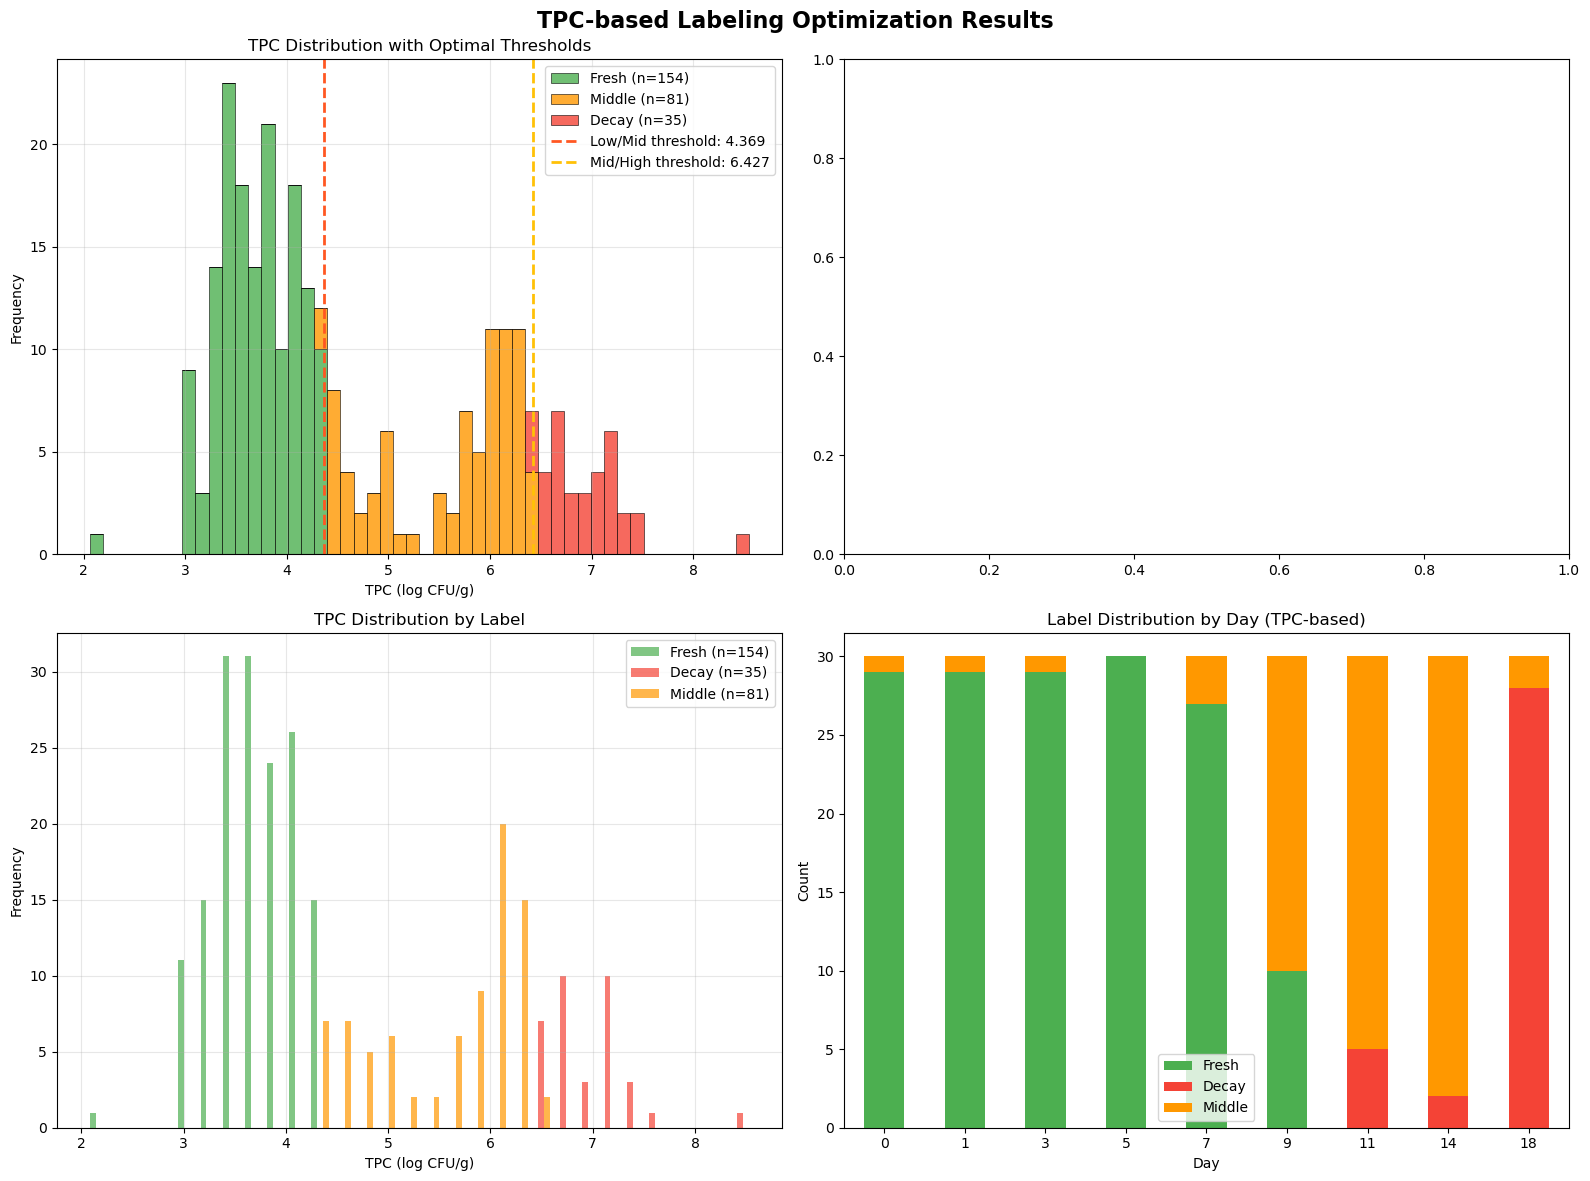


=== 2. 최적화 히스토리 플롯 ===


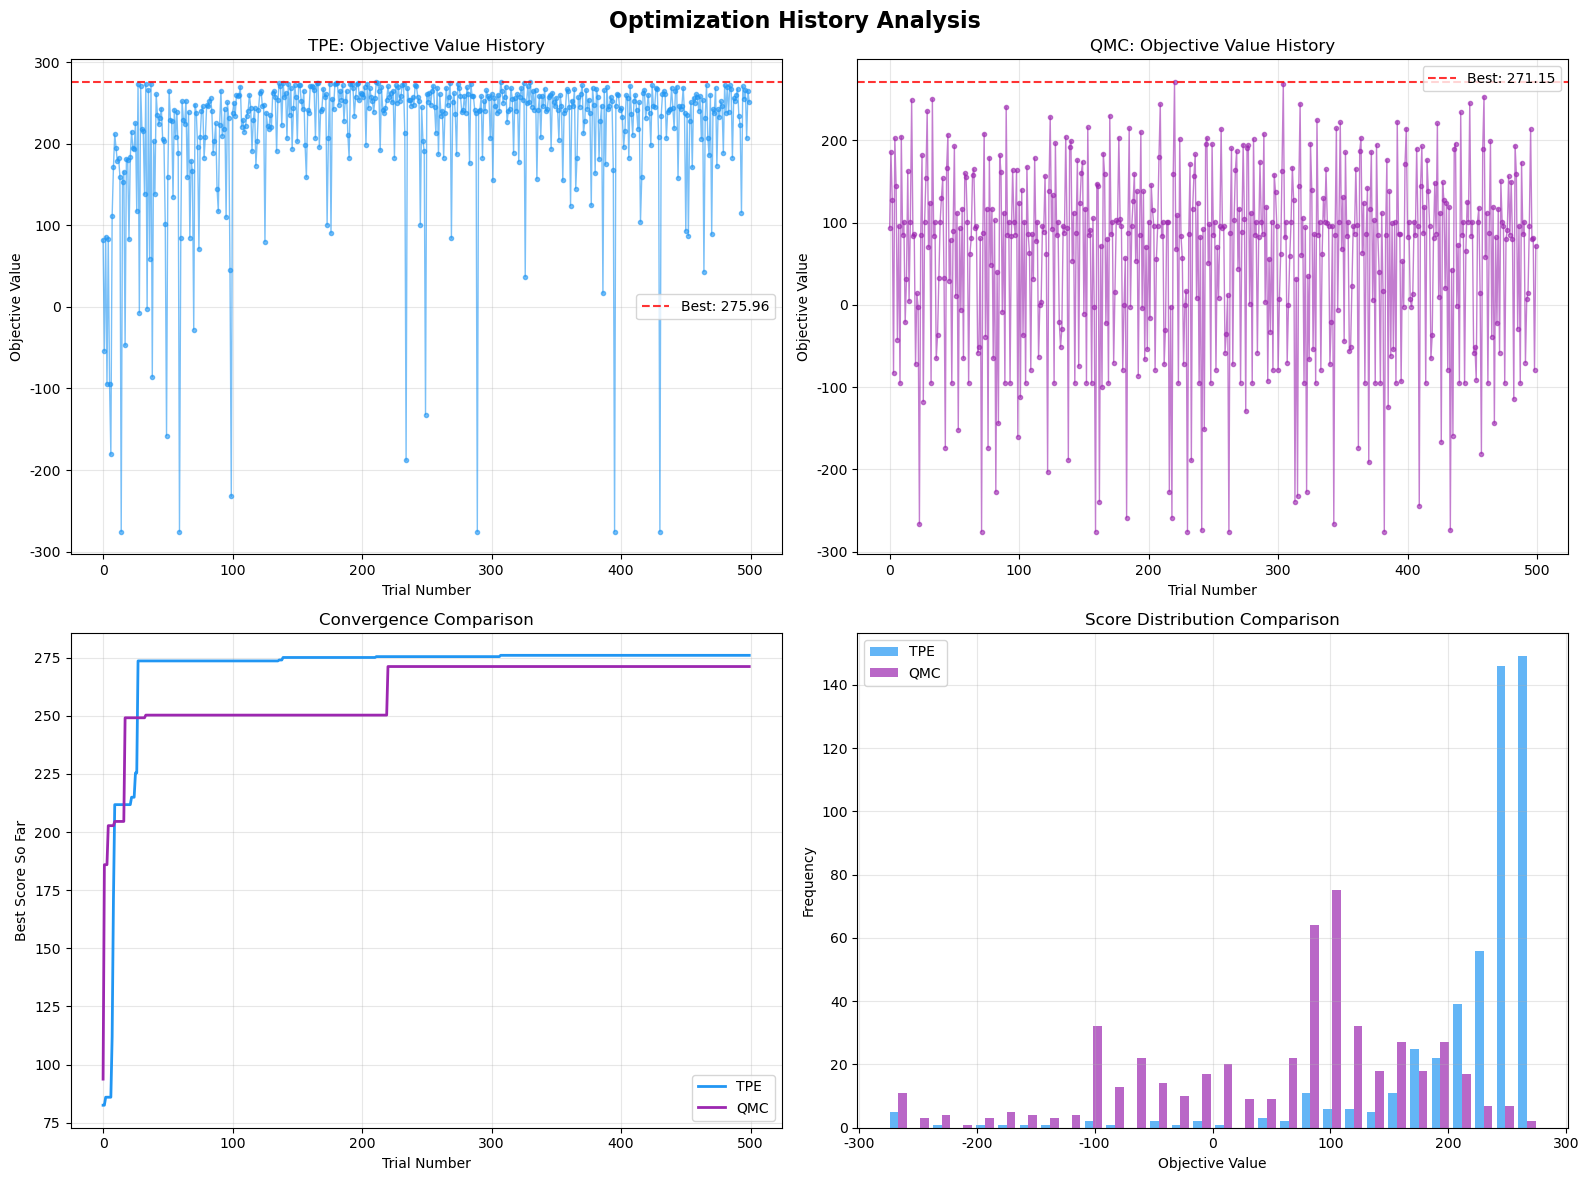


=== 3. 병렬 좌표 플롯 ===



=== 4. 파라미터 공간 시각화 ===


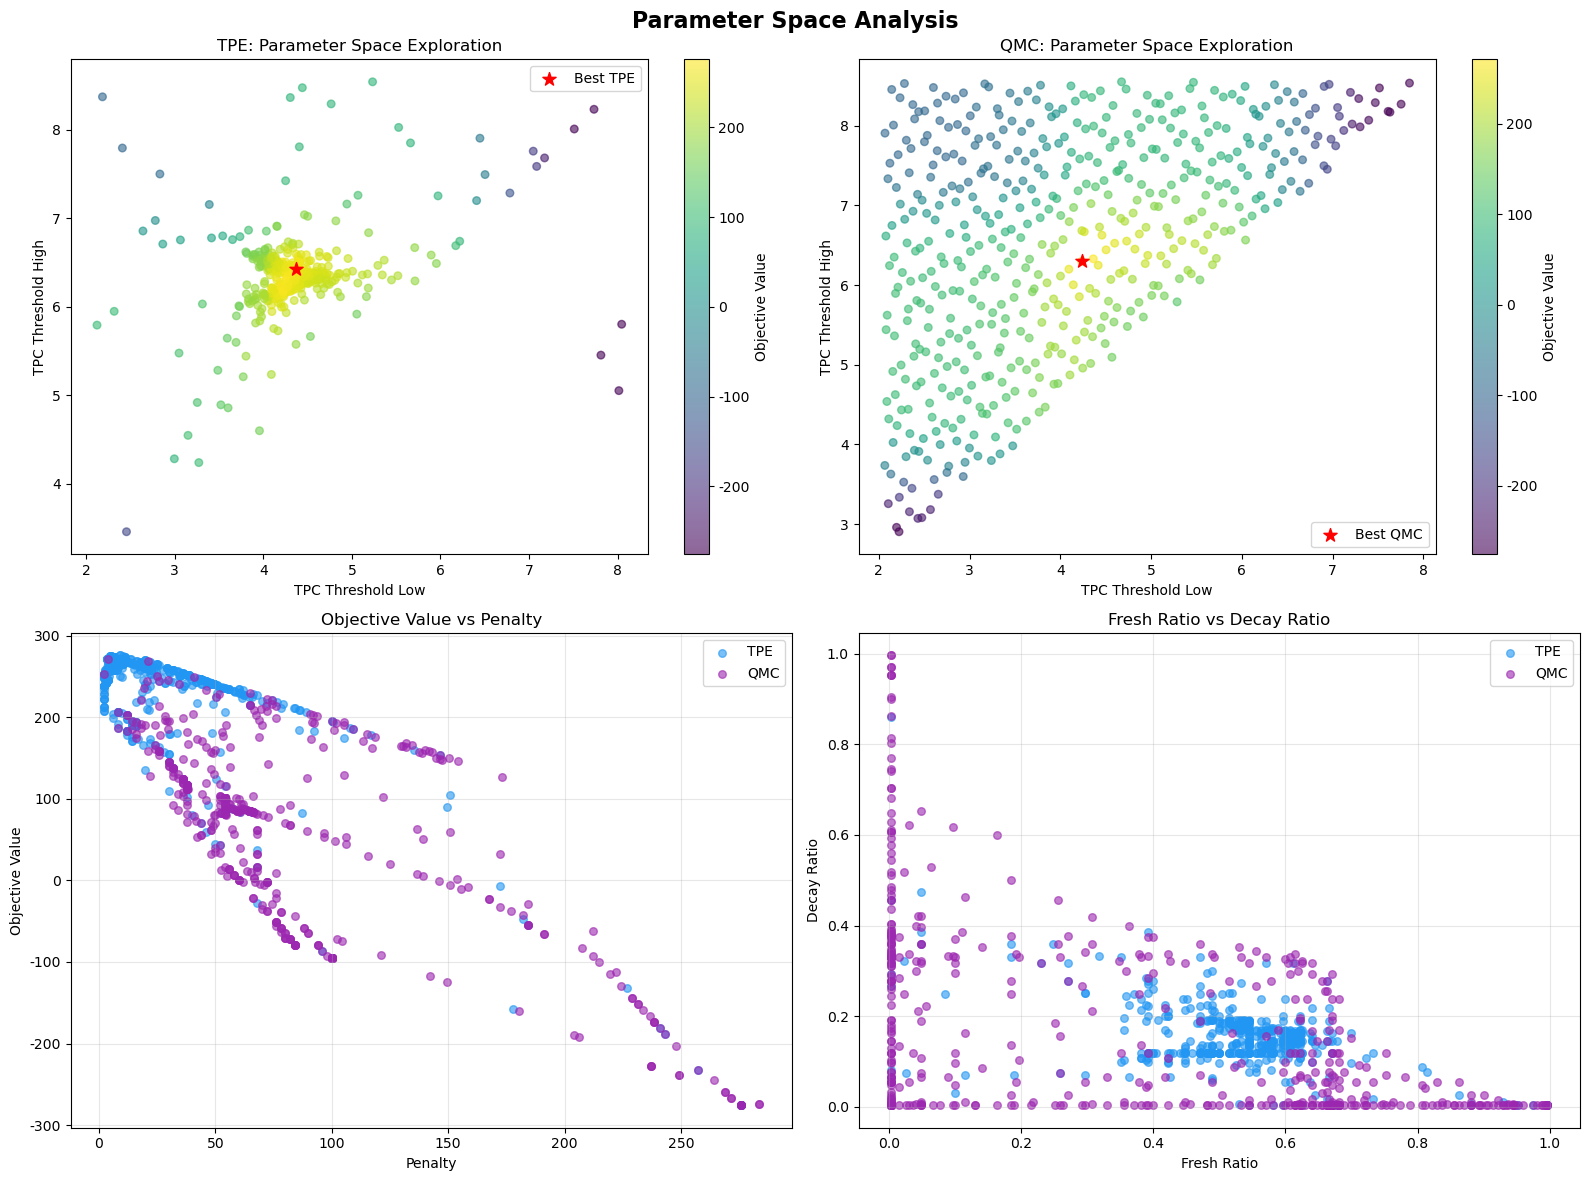


=== 5. 최적화 결과 요약 ===

📊 TPE vs QMC 성능 비교:
       Metric         TPE     QMC
   Best Score     275.963 271.148
   Mean Score     216.484  54.543
    Std Score      86.798 116.301
 Best TPC Low       4.369   4.235
Best TPC High       6.427   6.297
  Runtime (s) ~500 trials     2.7

🏆 최종 승자: TPE
성능 향상: 4.815

📈 최종 라벨링 결과:
Fresh: 154 (57.0%)
Decay: 35 (13.0%)
Middle: 81 (30.0%)

=== 시각화 완료 ===


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

print("=== 최적화 과정 및 결과 시각화 ===")

# 기본 matplotlib 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# Color palette
colors = {
    'fresh': '#4CAF50',      # Green
    'decay': '#F44336',      # Red  
    'middle': '#FF9800',     # Orange
    'tpe': '#2196F3',        # Blue
    'qmc': '#9C27B0',        # Purple
    'threshold_low': '#FF5722',   # Deep Orange
    'threshold_high': '#FFC107'   # Amber
}

# 1. TPC Distribution and Threshold Visualization (첨부 이미지 스타일)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('TPC-based Labeling Optimization Results', fontsize=16, fontweight='bold')

# 1-1. TPC Distribution with Optimal Thresholds (구간별 색상 + legend 구분)
fresh_mask = df_tpc['TPC (log CFU/g)'] < tpc_thr_low_final
middle_mask = (df_tpc['TPC (log CFU/g)'] >= tpc_thr_low_final) & (df_tpc['TPC (log CFU/g)'] < tpc_thr_high_final)
decay_mask = df_tpc['TPC (log CFU/g)'] >= tpc_thr_high_final

fresh_data = df_tpc.loc[fresh_mask, 'TPC (log CFU/g)']
middle_data = df_tpc.loc[middle_mask, 'TPC (log CFU/g)']
decay_data = df_tpc.loc[decay_mask, 'TPC (log CFU/g)']

n_fresh = len(fresh_data)
n_middle = len(middle_data)
n_decay = len(decay_data)

axes[0, 0].hist(
    [fresh_data, middle_data, decay_data],
    bins=50,
    color=[colors['fresh'], colors['middle'], colors['decay']],
    label=[f'Fresh (n={n_fresh})', f'Middle (n={n_middle})', f'Decay (n={n_decay})'],
    stacked=True,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5
)
axes[0, 0].axvline(x=tpc_thr_low_final, color=colors['threshold_low'],
                   linestyle='--', linewidth=2,
                   label=f'Low/Mid threshold: {tpc_thr_low_final:.3f}')
axes[0, 0].axvline(x=tpc_thr_high_final, color=colors['threshold_high'],
                   linestyle='--', linewidth=2,
                   label=f'Mid/High threshold: {tpc_thr_high_final:.3f}')
axes[0, 0].set_title('TPC Distribution with Optimal Thresholds')
axes[0, 0].set_xlabel('TPC (log CFU/g)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 1-3. TPC Distribution by Label (histogram) - 문제 해결
fresh_data = df_tpc[df_tpc['Label_Final'] == 0]['TPC (log CFU/g)']
decay_data = df_tpc[df_tpc['Label_Final'] == 1]['TPC (log CFU/g)']
middle_data = df_tpc[df_tpc['Label_Final'] == 2]['TPC (log CFU/g)']

n_fresh = len(fresh_data)
n_decay = len(decay_data)
n_middle = len(middle_data)

# 올바른 축에 히스토그램 그리기
axes[1, 0].hist([fresh_data, decay_data, middle_data], 
                bins=30, alpha=0.7, 
                color=[colors['fresh'], colors['decay'], colors['middle']], 
                label=[f'Fresh (n={n_fresh})', f'Decay (n={n_decay})', f'Middle (n={n_middle})'],
                stacked=False)
axes[1, 0].set_title('TPC Distribution by Label')
axes[1, 0].set_xlabel('TPC (log CFU/g)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 1-4. Label Distribution by Day (stacked bar)
day_label_counts = df_tpc.groupby('Day')['Label_Final'].value_counts().unstack(fill_value=0)
day_label_counts.plot(kind='bar', stacked=True, ax=axes[1, 1], 
                     color=[colors['fresh'], colors['decay'], colors['middle']])
axes[1, 1].set_title('Label Distribution by Day (TPC-based)')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(['Fresh', 'Decay', 'Middle'])
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# 2. Optimization History Plot
print("\n=== 2. 최적화 히스토리 플롯 ===")

# Extract TPE trials data
tpe_trials_data = []
for trial in study_tpe.trials:
    if trial.state == optuna.trial.TrialState.COMPLETE:
        tpe_trials_data.append({
            'trial_number': trial.number,
            'score': trial.value,
            'tpc_thr_low': trial.params['tpc_thr_low'],
            'tpc_thr_high': trial.params['tpc_thr_high'],
            'penalty': trial.user_attrs['stats']['penalty'] if 'stats' in trial.user_attrs else 0,
            'fresh_ratio': trial.user_attrs['stats']['fresh_ratio'] if 'stats' in trial.user_attrs else 0,
            'decay_ratio': trial.user_attrs['stats']['decay_ratio'] if 'stats' in trial.user_attrs else 0
        })

tpe_df = pd.DataFrame(tpe_trials_data)

# Organize QMC results data
qmc_df = pd.DataFrame([
    {
        'trial_number': result['trial'],
        'score': result['score'],
        'tpc_thr_low': result['tpc_thr_low'],
        'tpc_thr_high': result['tpc_thr_high'],
        'penalty': result['stats']['penalty'],
        'fresh_ratio': result['stats']['fresh_ratio'],
        'decay_ratio': result['stats']['decay_ratio']
    }
    for result in all_qmc_results
])

# Optimization History Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Optimization History Analysis', fontsize=16, fontweight='bold')

# 2-1. Objective Value History (TPE)
axes[0, 0].plot(tpe_df['trial_number'], tpe_df['score'], 'o-', 
                color=colors['tpe'], alpha=0.6, linewidth=1, markersize=3)
axes[0, 0].axhline(y=study_tpe.best_value, color='red', linestyle='--', 
                   alpha=0.8, label=f'Best: {study_tpe.best_value:.2f}')
axes[0, 0].set_title('TPE: Objective Value History')
axes[0, 0].set_xlabel('Trial Number')
axes[0, 0].set_ylabel('Objective Value')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2-2. Objective Value History (QMC)
axes[0, 1].plot(qmc_df['trial_number'], qmc_df['score'], 'o-', 
                color=colors['qmc'], alpha=0.6, linewidth=1, markersize=3)
axes[0, 1].axhline(y=best_qmc_score, color='red', linestyle='--', 
                   alpha=0.8, label=f'Best: {best_qmc_score:.2f}')
axes[0, 1].set_title('QMC: Objective Value History')
axes[0, 1].set_xlabel('Trial Number')
axes[0, 1].set_ylabel('Objective Value')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 2-3. Convergence Comparison (Cumulative Best)
tpe_cummax = tpe_df['score'].cummax()
qmc_cummax = qmc_df['score'].cummax()

axes[1, 0].plot(tpe_df['trial_number'], tpe_cummax, 
                label='TPE', color=colors['tpe'], linewidth=2)
axes[1, 0].plot(qmc_df['trial_number'], qmc_cummax, 
                label='QMC', color=colors['qmc'], linewidth=2)
axes[1, 0].set_title('Convergence Comparison')
axes[1, 0].set_xlabel('Trial Number')
axes[1, 0].set_ylabel('Best Score So Far')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 2-4. Score Distribution Comparison
axes[1, 1].hist([tpe_df['score'], qmc_df['score']], 
                bins=30, alpha=0.7, 
                color=[colors['tpe'], colors['qmc']], 
                label=['TPE', 'QMC'])
axes[1, 1].set_title('Score Distribution Comparison')
axes[1, 1].set_xlabel('Objective Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Parallel Coordinate Plot
print("\n=== 3. 병렬 좌표 플롯 ===")

# Select top 50 trials (TPE + QMC)
top_tpe = tpe_df.nlargest(25, 'score')
top_qmc = qmc_df.nlargest(25, 'score')

# Prepare data
top_tpe['method'] = 'TPE'
top_qmc['method'] = 'QMC'
combined_top = pd.concat([top_tpe, top_qmc], ignore_index=True)

# Create Parallel Coordinate Plot with Plotly
fig_parallel = go.Figure(data=
    go.Parcoords(
        line=dict(color=combined_top['score'],
                  colorscale='Viridis',
                  showscale=True,
                  colorbar=dict(title="Objective Value")),
        dimensions=list([
            dict(range=[combined_top['tpc_thr_low'].min(), combined_top['tpc_thr_low'].max()],
                 constraintrange=[combined_top['tpc_thr_low'].min(), combined_top['tpc_thr_low'].max()],
                 label="TPC Threshold Low", values=combined_top['tpc_thr_low']),
            dict(range=[combined_top['tpc_thr_high'].min(), combined_top['tpc_thr_high'].max()],
                 constraintrange=[combined_top['tpc_thr_high'].min(), combined_top['tpc_thr_high'].max()],
                 label="TPC Threshold High", values=combined_top['tpc_thr_high']),
            dict(range=[combined_top['penalty'].min(), combined_top['penalty'].max()],
                 constraintrange=[combined_top['penalty'].min(), combined_top['penalty'].max()],
                 label="Penalty", values=combined_top['penalty']),
            dict(range=[combined_top['fresh_ratio'].min(), combined_top['fresh_ratio'].max()],
                 constraintrange=[combined_top['fresh_ratio'].min(), combined_top['fresh_ratio'].max()],
                 label="Fresh Ratio", values=combined_top['fresh_ratio']),
            dict(range=[combined_top['decay_ratio'].min(), combined_top['decay_ratio'].max()],
                 constraintrange=[combined_top['decay_ratio'].min(), combined_top['decay_ratio'].max()],
                 label="Decay Ratio", values=combined_top['decay_ratio']),
            dict(range=[combined_top['score'].min(), combined_top['score'].max()],
                 constraintrange=[combined_top['score'].min(), combined_top['score'].max()],
                 label="Objective Value", values=combined_top['score'])
        ])
    )
)

fig_parallel.update_layout(
    title="Parallel Coordinate Plot - Top 50 Trials (TPE + QMC)",
    font=dict(size=12)
)

fig_parallel.show()

# 4. Parameter Space Visualization
print("\n=== 4. 파라미터 공간 시각화 ===")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Parameter Space Analysis', fontsize=16, fontweight='bold')

# 4-1. TPE Parameter Space (TPC Low vs High)
scatter1 = axes[0, 0].scatter(tpe_df['tpc_thr_low'], tpe_df['tpc_thr_high'], 
                             c=tpe_df['score'], cmap='viridis', alpha=0.6, s=30)
axes[0, 0].scatter(study_tpe.best_params['tpc_thr_low'], 
                  study_tpe.best_params['tpc_thr_high'], 
                  color='red', s=100, marker='*', label='Best TPE')
axes[0, 0].set_title('TPE: Parameter Space Exploration')
axes[0, 0].set_xlabel('TPC Threshold Low')
axes[0, 0].set_ylabel('TPC Threshold High')
axes[0, 0].legend()
plt.colorbar(scatter1, ax=axes[0, 0], label='Objective Value')

# 4-2. QMC Parameter Space (TPC Low vs High)
scatter2 = axes[0, 1].scatter(qmc_df['tpc_thr_low'], qmc_df['tpc_thr_high'], 
                             c=qmc_df['score'], cmap='viridis', alpha=0.6, s=30)
axes[0, 1].scatter(best_qmc_params['tpc_thr_low'], 
                  best_qmc_params['tpc_thr_high'], 
                  color='red', s=100, marker='*', label='Best QMC')
axes[0, 1].set_title('QMC: Parameter Space Exploration')
axes[0, 1].set_xlabel('TPC Threshold Low')
axes[0, 1].set_ylabel('TPC Threshold High')
axes[0, 1].legend()
plt.colorbar(scatter2, ax=axes[0, 1], label='Objective Value')

# 4-3. Score vs Penalty Relationship
axes[1, 0].scatter(tpe_df['penalty'], tpe_df['score'], 
                  alpha=0.6, color=colors['tpe'], label='TPE', s=30)
axes[1, 0].scatter(qmc_df['penalty'], qmc_df['score'], 
                  alpha=0.6, color=colors['qmc'], label='QMC', s=30)
axes[1, 0].set_title('Objective Value vs Penalty')
axes[1, 0].set_xlabel('Penalty')
axes[1, 0].set_ylabel('Objective Value')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4-4. Fresh vs Decay Ratio
axes[1, 1].scatter(tpe_df['fresh_ratio'], tpe_df['decay_ratio'], 
                  alpha=0.6, color=colors['tpe'], label='TPE', s=30)
axes[1, 1].scatter(qmc_df['fresh_ratio'], qmc_df['decay_ratio'], 
                  alpha=0.6, color=colors['qmc'], label='QMC', s=30)
axes[1, 1].set_title('Fresh Ratio vs Decay Ratio')
axes[1, 1].set_xlabel('Fresh Ratio')
axes[1, 1].set_ylabel('Decay Ratio')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Detailed Statistical Summary
print("\n=== 5. 최적화 결과 요약 ===")

# Performance comparison table
performance_summary = pd.DataFrame({
    'Metric': ['Best Score', 'Mean Score', 'Std Score', 'Best TPC Low', 'Best TPC High', 'Runtime (s)'],
    'TPE': [
        f"{study_tpe.best_value:.3f}",
        f"{tpe_df['score'].mean():.3f}",
        f"{tpe_df['score'].std():.3f}",
        f"{study_tpe.best_params['tpc_thr_low']:.3f}",
        f"{study_tpe.best_params['tpc_thr_high']:.3f}",
        "~500 trials"
    ],
    'QMC': [
        f"{best_qmc_score:.3f}",
        f"{qmc_df['score'].mean():.3f}",
        f"{qmc_df['score'].std():.3f}",
        f"{best_qmc_params['tpc_thr_low']:.3f}",
        f"{best_qmc_params['tpc_thr_high']:.3f}",
        f"{total_time:.1f}"
    ]
})

print("\n📊 TPE vs QMC 성능 비교:")
print(performance_summary.to_string(index=False))

print(f"\n🏆 최종 승자: {winner}")
print(f"성능 향상: {improvement:.3f}")

print(f"\n📈 최종 라벨링 결과:")
final_label_counts = df_tpc['Label_Final'].value_counts().sort_index()
total_samples = len(df_tpc)
for label, count in final_label_counts.items():
    label_name = ['Fresh', 'Decay', 'Middle'][label]
    print(f"{label_name}: {count} ({count/total_samples*100:.1f}%)")

print("\n=== 시각화 완료 ===")

## **k means**  클러스터로 label 확인

=== KMeans 기반 TBARS/TPC 임계값 탐색 ===
KMeans TBARS 임계값 (low/mid/high): 0.219, 0.285
KMeans TPC 임계값 (low/mid/high): 3.927, 5.368


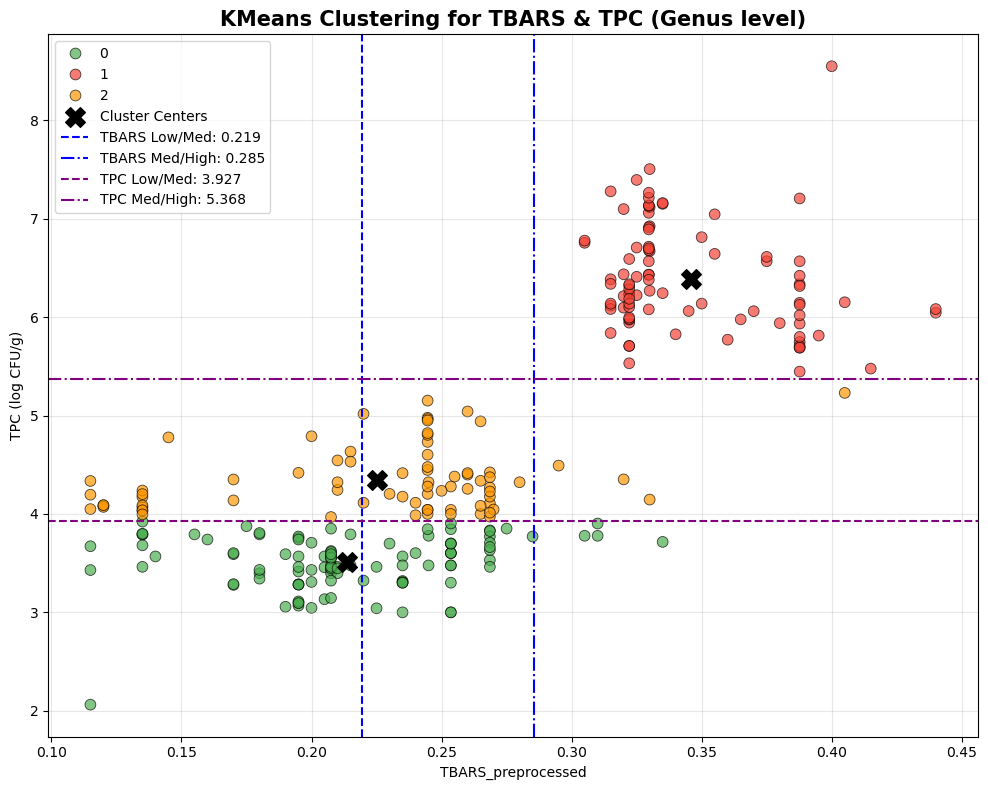


=== KMeans 기반 라벨 분포 ===
Fresh: 106개 (39.3%)
Decay: 89개 (33.0%)
Middle: 75개 (27.8%)

=== Day별 라벨 분포 (KMeans) ===
KMeans_Label_Final   0   1   2
Day                           
0                   13   0  17
1                   29   0   1
3                   28   0   2
5                   23   0   7
7                   12   0  18
9                    1   0  29
11                   0  29   1
14                   0  30   0
18                   0  30   0


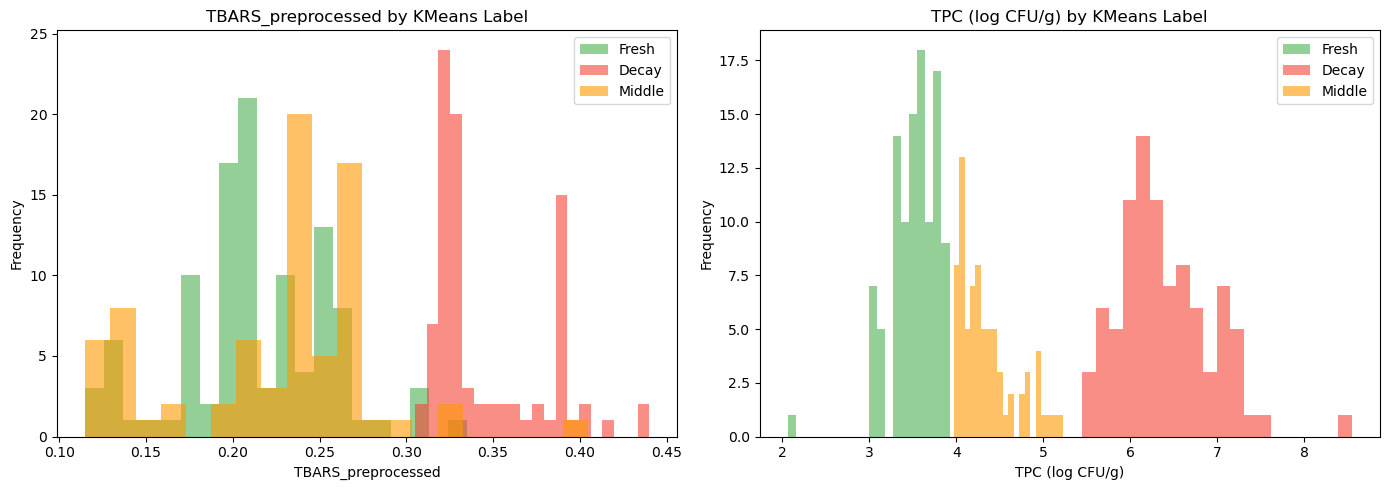

In [9]:
# --- KMeans 기반 TBARS/TPC 임계값 자동 탐색 및 시각화 ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

print("=== KMeans 기반 TBARS/TPC 임계값 탐색 ===")

# Genus level 데이터 준비 (TBARS 전처리 포함)
df_genus = final_taxonomic_levels[-1][1].copy()
if 'Day' not in df_genus.columns:
    df_genus['Day'] = df_genus['Description'].str.extract(r'A(\d+)', expand=False).astype(int)
if 'TBARS_preprocessed' not in df_genus.columns:
    import pickle
    with open('tbars_preprocessed_info.pkl', 'rb') as f:
        tbars_preprocess_info = pickle.load(f)
    tbars_map = dict(zip(
        tbars_preprocess_info['processed_df']['Description'],
        tbars_preprocess_info['processed_df']['TBARS_preprocessed']
    ))
    df_genus['TBARS_preprocessed'] = df_genus['Description'].map(tbars_map)

# 1. TBARS/TPC 2D KMeans 클러스터링 (n_clusters=3)
X = df_genus[['TBARS_preprocessed', 'TPC (log CFU/g)']].values
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
labels = kmeans.fit_predict(X)
df_genus['KMeans_Label'] = labels

# 2. 클러스터 중심값 기준으로 label 의미 부여 (Fresh/Decay/Middle)
centers = kmeans.cluster_centers_
# Fresh: TBARS/TPC 모두 낮음, Decay: 모두 높음, Middle: 중간
center_df = pd.DataFrame(centers, columns=['TBARS_preprocessed', 'TPC (log CFU/g)'])
center_df['cluster'] = center_df.index
center_df['sum'] = center_df['TBARS_preprocessed'] + center_df['TPC (log CFU/g)']
sorted_centers = center_df.sort_values('sum').reset_index(drop=True)
cluster_map = {sorted_centers.loc[0, 'cluster']: 0,  # Fresh
               sorted_centers.loc[2, 'cluster']: 1,  # Decay
               sorted_centers.loc[1, 'cluster']: 2}  # Middle
df_genus['KMeans_Label_Final'] = df_genus['KMeans_Label'].map(cluster_map)

# 3. 각 클러스터의 TBARS/TPC 임계값(중앙값) 추출
tbars_thresholds = sorted(center_df['TBARS_preprocessed'])
tpc_thresholds = sorted(center_df['TPC (log CFU/g)'])

tbars_thr_kmeans_low = tbars_thresholds[0] + (tbars_thresholds[1] - tbars_thresholds[0]) / 2
tbars_thr_kmeans_high = tbars_thresholds[1] + (tbars_thresholds[2] - tbars_thresholds[1]) / 2
tpc_thr_kmeans_low = tpc_thresholds[0] + (tpc_thresholds[1] - tpc_thresholds[0]) / 2
tpc_thr_kmeans_high = tpc_thresholds[1] + (tpc_thresholds[2] - tpc_thresholds[1]) / 2

print(f"KMeans TBARS 임계값 (low/mid/high): {tbars_thr_kmeans_low:.3f}, {tbars_thr_kmeans_high:.3f}")
print(f"KMeans TPC 임계값 (low/mid/high): {tpc_thr_kmeans_low:.3f}, {tpc_thr_kmeans_high:.3f}")

# 4. 시각화: 2D scatter + 클러스터 + 임계값
plt.figure(figsize=(10, 8))
palette = {0: '#4CAF50', 1: '#F44336', 2: '#FF9800'}
label_names = {0: 'Fresh', 1: 'Decay', 2: 'Middle'}
sns.scatterplot(
    data=df_genus,
    x='TBARS_preprocessed', y='TPC (log CFU/g)',
    hue='KMeans_Label_Final', palette=palette, alpha=0.7, s=60, edgecolor='k'
)
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, marker='X', label='Cluster Centers')
plt.axvline(tbars_thr_kmeans_low, color='blue', linestyle='--', label=f'TBARS Low/Med: {tbars_thr_kmeans_low:.3f}')
plt.axvline(tbars_thr_kmeans_high, color='blue', linestyle='-.', label=f'TBARS Med/High: {tbars_thr_kmeans_high:.3f}')
plt.axhline(tpc_thr_kmeans_low, color='purple', linestyle='--', label=f'TPC Low/Med: {tpc_thr_kmeans_low:.3f}')
plt.axhline(tpc_thr_kmeans_high, color='purple', linestyle='-.', label=f'TPC Med/High: {tpc_thr_kmeans_high:.3f}')
plt.title('KMeans Clustering for TBARS & TPC (Genus level)', fontsize=15, fontweight='bold')
plt.xlabel('TBARS_preprocessed')
plt.ylabel('TPC (log CFU/g)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. 라벨 분포 및 Day별 분포 요약
print("\n=== KMeans 기반 라벨 분포 ===")
for k, v in label_names.items():
    n = (df_genus['KMeans_Label_Final'] == k).sum()
    print(f"{v}: {n}개 ({n/len(df_genus)*100:.1f}%)")
print("\n=== Day별 라벨 분포 (KMeans) ===")
print(df_genus.groupby('Day')['KMeans_Label_Final'].value_counts().unstack(fill_value=0))

# 6. TBARS/TPC별 히스토그램 (클러스터별)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for k, color in palette.items():
    axes[0].hist(df_genus[df_genus['KMeans_Label_Final'] == k]['TBARS_preprocessed'], bins=20, alpha=0.6, color=color, label=label_names[k])
    axes[1].hist(df_genus[df_genus['KMeans_Label_Final'] == k]['TPC (log CFU/g)'], bins=20, alpha=0.6, color=color, label=label_names[k])
axes[0].set_title('TBARS_preprocessed by KMeans Label')
axes[0].set_xlabel('TBARS_preprocessed')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[1].set_title('TPC (log CFU/g) by KMeans Label')
axes[1].set_xlabel('TPC (log CFU/g)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
plt.tight_layout()
plt.show()